In [1]:
!pip install pandas scikit-learn seaborn matplotlib plotly wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load full dataset (semicolon-separated)
df = pd.read_csv('bank-full.csv', sep=';')
print(df.shape)  # (45211, 17)
print(df.head())
print(df['y'].value_counts(normalize=True))  # Imbalanced: ~11% 'yes'


  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   --- ----------------------------------- 30.7/306.1 kB 187.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/306.1 kB 187.9 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/306.1 kB 233.8 kB/s eta 0:00:02
   --------- ----------------------------- 71.7/306.1 kB 262.6 kB/s eta 0:00:01
   ----------------- -------------------- 143.4/306.1 kB 405.9 kB/s eta 0:00:01
   ------------------- ------------------ 153.6/306.1 kB 416.7 kB/s eta 0:00:01
   ----------------------------- -------- 235.5/306.1 kB 533.8 kB/s eta 0:00:01
   ----------

Subscription rate: 0.11698480458295547

job conversion rates:
 job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: yes, dtype: float64

marital conversion rates:
 marital
single      0.149492
divorced    0.119455
married     0.101235
Name: yes, dtype: float64

education conversion rates:
 education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: yes, dtype: float64


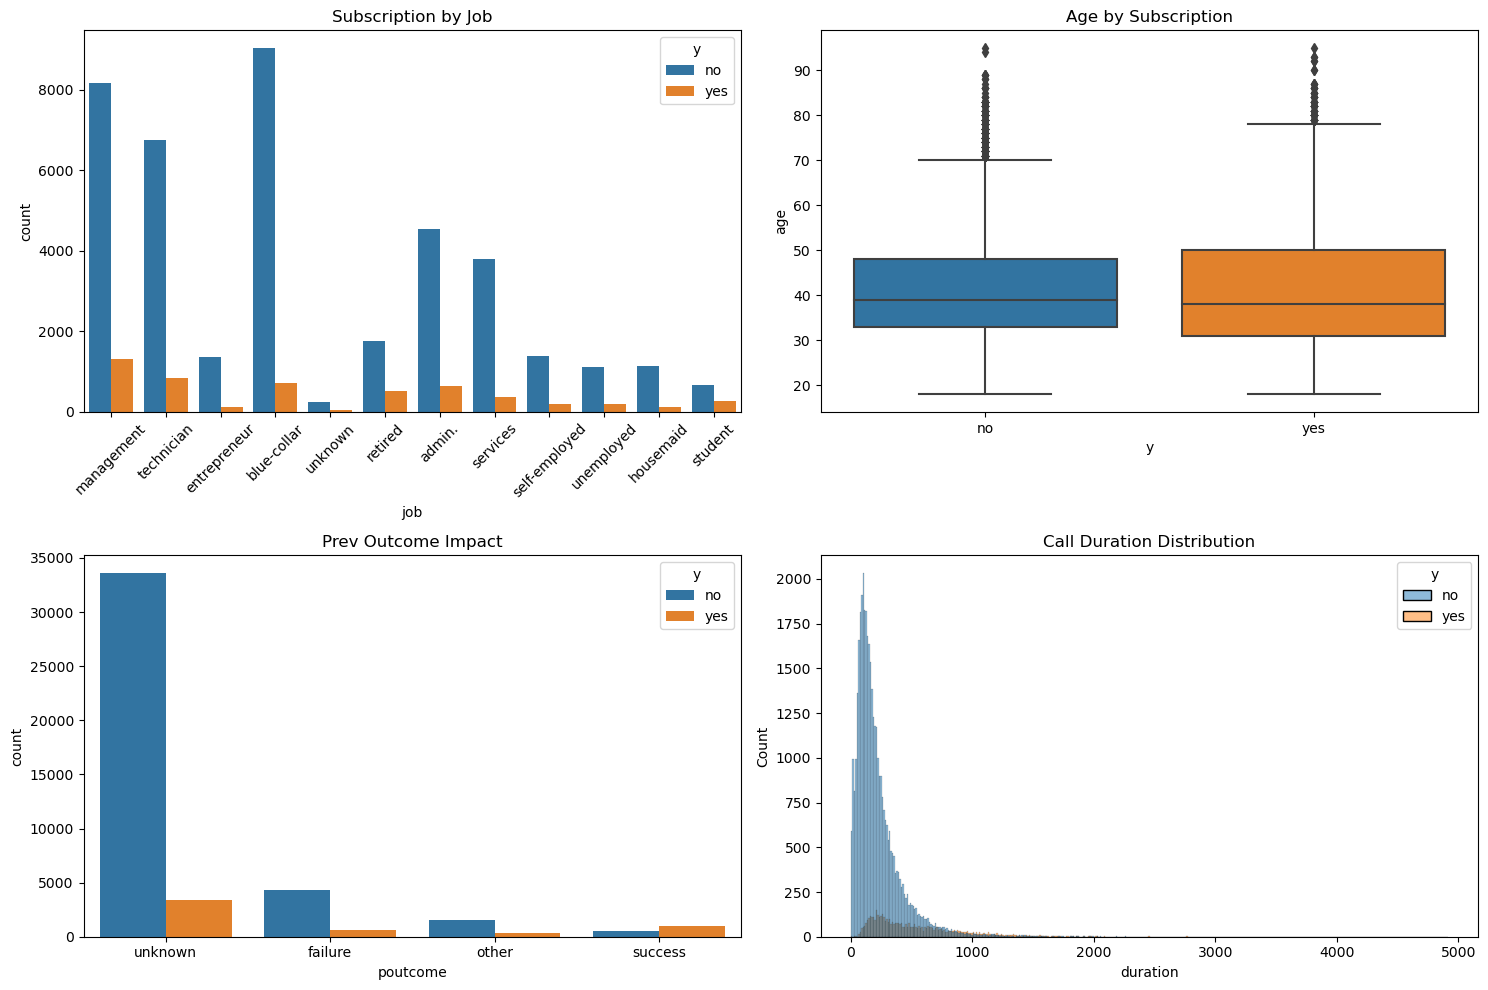

In [2]:
# Target: subscription rate
print("Subscription rate:", df['y'].value_counts(normalize=True)['yes'])

# Numeric features
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df[num_cols].describe()

# Categorical top features
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
for col in cat_cols[:3]:  # Sample
    conv = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)['yes']
    print(f"\n{col} conversion rates:\n", conv.sort_values(ascending=False))

# Visuals
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(data=df, x='job', hue='y', ax=axes[0,0]).tick_params(axis='x', rotation=45)
axes[0,0].set_title('Subscription by Job')
sns.boxplot(data=df, x='y', y='age', ax=axes[0,1])
axes[0,1].set_title('Age by Subscription')
sns.countplot(data=df, x='poutcome', hue='y', ax=axes[1,0])
axes[1,0].set_title('Prev Outcome Impact')
sns.histplot(data=df, x='duration', hue='y', ax=axes[1,1])
axes[1,1].set_title('Call Duration Distribution')
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.66      0.34      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

AUC: 0.926150047406941


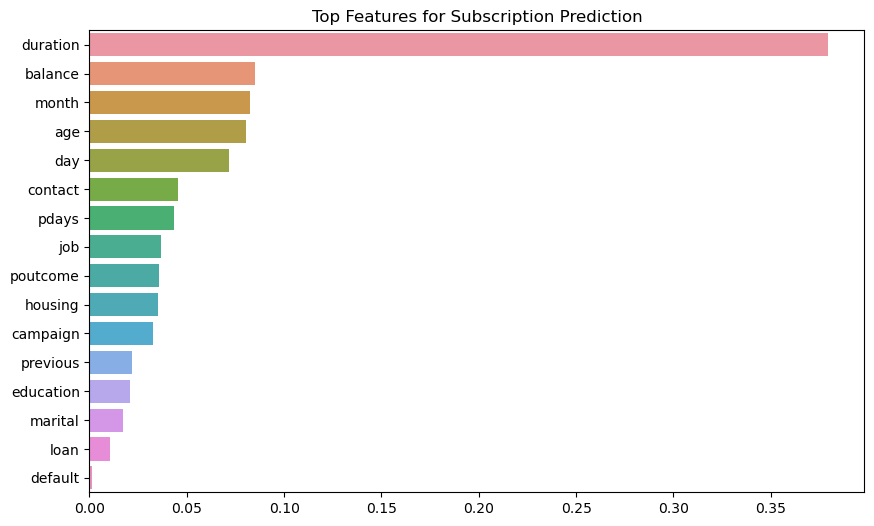

In [3]:
# Prep data
le = LabelEncoder()
for col in df.select_dtypes('object').columns[:-1]:  # Exclude target
    df[col] = le.fit_transform(df[col])
df['y'] = df['y'].map({'no':0, 'yes':1})

X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict & evaluate
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top Features for Subscription Prediction')
plt.show()
